In [150]:
from collections import Counter
from datetime import datetime, timezone
import inspect
import json
import logging
import matplotlib.pyplot as plt
import mlflow
import nltk
from nltk.corpus import stopwords
import numpy as np
import os
from pathlib import Path
import pandas as pd
import random
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_curve
import shutil
import torch
from torch import nn, optim
from torch.amp import GradScaler, autocast
from torch.cuda import Event
import torch.nn.functional as F
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts, CosineAnnealingLR, OneCycleLR, ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchmetrics.classification import BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score, AUROC, AveragePrecision, PrecisionRecallCurve
from tqdm.notebook import tqdm
import warnings
import zipfile
warnings.filterwarnings("ignore", message=".*Pickle or CloudPickle.*")
nltk.download('stopwords', quiet=True)

True

In [151]:
%load_ext requirements

The requirements extension is already loaded. To reload it, use:
  %reload_ext requirements


In [152]:
class SystemConfig:
    IS_DETERMINISTIC = False
    _PROJECT_ROOT = Path.cwd()  # research/ folder
    _DB_PATH = _PROJECT_ROOT / "mlflow-quora-questions-pairs.db"
    MLFLOW_TRACKING_URI = f"sqlite:///{_DB_PATH.as_posix()}"
    NEXT_LINE_COUNTER = 180
    SEED = 28
    USED_SCALER = False
    NEXT_LINE_COUNTER = 180
    @staticmethod
    def get_device():
        '''
        Detects the best available device for PyTorch.
        Priority: TPU -> GPU (CUDA) -> CPU
        '''
        # 1. Check for TPU (requires torch_xla)
        try:
            import torch_xla.core.xla_model as xm
            device = xm.xla_device()
            print(f">>> Using TPU: {device}")
        except ImportError:
            # 2. Check for GPU (CUDA)
            if torch.cuda.is_available():
                device = torch.device("cuda")
                print(f">>> Using GPU: {torch.cuda.get_device_name(0)}")
            # 3. Fallback to CPU
            else:
                device = torch.device("cpu")
                print(">>> Using CPU")
                
        return device
    DEVICE = get_device.__func__()

    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

>>> Using GPU: NVIDIA GeForce GTX 1650


In [153]:
class PathConfig:
    ROOT_DIR = Path().cwd()
    EMB_DIR = ROOT_DIR.parent.parent
    EMB_PATH = EMB_DIR / "glove.6B.100d.txt"
    ARTIFACT_DIR = ROOT_DIR / "artifacts"
    REQ_TEXT = ROOT_DIR / "requirements.txt"
    REQ_SCRIPT = ROOT_DIR / "requirements.py"
    MODEL_SCRIPT = ROOT_DIR / "model_architecture.py"
    NOTEBOOK_PATH = ROOT_DIR / "LSTM-attention-train.ipynb"
    DATA_DIR = ROOT_DIR / "data"
    MLFLOW_DIR = ROOT_DIR / "mlruns"
    CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoint"
    CONFIG_PATH = ARTIFACT_DIR / "configs.json"
    HISTORY_PATH = ARTIFACT_DIR / "training_history.json"
    VOCABS_PATH = ARTIFACT_DIR / "vocabs.json"
    LABEL_MAPPING_PATH = ARTIFACT_DIR / "label_mapping.json"
    TRAIN_CSV_PATH = DATA_DIR / "train.csv"
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

    @classmethod
    def update_requirements(cls):
        from IPython import get_ipython
        ipython = get_ipython()
        if ipython:
            ipython.run_line_magic('updatereqs', str(cls.NOTEBOOK_PATH))

In [154]:
class TokenConfig:
    PAD_TOKEN = '<PAD>'
    UNK_TOKEN = '<UNK>'
    PAD_IDX = 0
    UNK_IDX = 1
    LOWERCASE = True
    UPPERCASE = False
    MAX_LENGTH = 50
    VOCAB_SIZE = 20000
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [155]:
class LoaderConfig:
    BATCH_SIZE = 128
    NUM_WORKERS = 0
    IS_PIN_MEMORY = True
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [156]:
class ModelConfig:
    MODEL_TYPE = "LSTM_attention"
    ATTENTION_TYPE = "MultiHead-Bahdanau"
    # Embedding
    LAYER_NORM_EMB = True
    FREEZE_TOKEN_EMBEDDING = True
    TOKEN_EMBEDDING = "gloVe-6B-100d"
    EMB_DIM = 100
    EMB_DP = 0.0
    # Model
    LOSS = "Consrative Loss"
    NUM_HEADS = 4
    BIDIRECTIONAL = True
    DROPOUT = 0.3
    HIDDEN_DIM = 384
    ATTENTION_DROPOUT = 0.0
    LAYER_NORM_LSTM = False
    LAYER_NORM_ATTENTION = False
    ATTENTION_PROJECTION = False
    if ATTENTION_PROJECTION:
        PROJECT_DIM = HIDDEN_DIM // 2
    MARGIN = 1.5
    MASK_FILL_NUM = -1e10
    SIAMESE_SIMILARITY_PARM = ["Euclidean Distance"]
    NUM_LAYERS = 2
    SKIP_CONNECTION = False
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [157]:
class TrainConfig:
    LOSS = "Consrative Loss"
    CLIP_NORM = 1.5
    EARLY_STOP_METRIC = "loss"
    CHECKPOINT_METRIC = "F1Score"
    if CHECKPOINT_METRIC == "loss":
        CHECKPOINT_MODE = "min"
    else:
        CHECKPOINT_MODE = "max"
    SCHEDULER_METRIC = "loss"
    EARLY_STOP_MIN_DELTA = 1e-4
    if EARLY_STOP_METRIC in ["F1Score", "Accuracy", "Precision", "Recall"]:
        EARLY_STOP_MODE = "max"
    elif EARLY_STOP_METRIC == "loss":
        EARLY_STOP_MODE = "min"
    EARLY_STOP_PATIENCE = 3
    EPOCHS = 50
    LEARNING_RATE = 1e-3
    METRICS_THRESHOLD = 0.5
    SCHEDULER_TYPE = "ReduceLROnPlateau"
    if SCHEDULER_TYPE == "ReduceLROnPlateau":
        SCHEDULER_FACTOR = 0.5
        SCHEDULER_MIN_LR = 1e-7
        SCHEDULER_PATIENCE = 2
        SCHEDULER_THRESHOLD = 0.01
        SCHEDULER_THRESHOLD_MODE = "rel"
        if SCHEDULER_METRIC in ["F1Score", "Accuracy", "Precision", "Recall"]:
            SCHEDULER_MODE = "max"
        elif SCHEDULER_METRIC == "loss":
            SCHEDULER_MODE = "min"
    elif SCHEDULER_TYPE == "CosineAnnealing":
        SCHEDULER_ETA_MIN = 1e-6
    elif SCHEDULER_TYPE == "CosineAnnealingWarmRestarts":
        SCHEDULER_T_0 = 5
        SCHEDULER_T_MUT = 2
        SCHEDULER_ETA_MIN = 1e-6
    elif SCHEDULER_TYPE == "OneCycleLR":
        SCHEDULER_PCT_START = 0.3
        SCHEDULER_DIV_FACTOR = 25
        SCHEDULER_FINAL_DIV_FACTOR = 1000

    TRAIN_TEST_SPLIT = 0.9
    UNFREEZE_EPOCH = 3
    WEIGHT_DECAY = 5e-4
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [158]:
class PostProcessingConfig:
    INFERENCE_THRESHOLD = 0.5
    METRICS_THRESHOLD = 0.5
    @classmethod
    def to_dict(cls):
        return {
            k.lower(): v for k, v in cls.__dict__.items()
            if not k.startswith("_")
            and not inspect.isroutine(v)   # functions, methods
            and not isinstance(v, (classmethod, staticmethod))
        }

In [159]:
for path in [PathConfig.EMB_PATH, PathConfig.TRAIN_CSV_PATH]:
    assert os.path.exists(path), f"File not found: {path}"

In [160]:
def seed_everything(seed, deterministic=False):
    '''
    Ensures absolute reproducibility.
    '''
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    if deterministic:
        # Only use these for the final "Gold" run to ensure exact results
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        print(">>> Using STRICT Deterministic mode (Slower).")
    else:
        # Benchmark=True allows cuDNN to find the fastest kernels for your hardware
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        print(">>> Using PROTOTYPING mode (Faster).")
    print(f">>> For Reproducibility, Everything seeded with {seed}!")



In [161]:
def set_scaler(config=SystemConfig):
    if config.USED_SCALER:
        scaler = GradScaler(device=sys_cfg.DEVICE.type, enabled=(sys_cfg.DEVICE.type == 'cuda'))
        print(">>> Scaler used in training")
    else:
        scaler = None
        print(">>> Scaler is not Used")

In [162]:
def clean_artifact_directory(artifact_dir: Path):
    if artifact_dir.exists():
        shutil.rmtree(artifact_dir)
        print(f">>> Cleaned local artifact directory: {artifact_dir}")
    artifact_dir.mkdir(parents=True, exist_ok=True)

In [163]:
sys_cfg = SystemConfig()
path_cfg = PathConfig()
token_cfg = TokenConfig()
train_cfg = TrainConfig()
loader_cfg = LoaderConfig()
model_cfg = ModelConfig()
postprc_cfg = PostProcessingConfig()
print(">>> All Configs are set successfully!")
path_cfg.update_requirements()
scaler = set_scaler(sys_cfg)
seed_everything(sys_cfg.SEED, deterministic=sys_cfg.IS_DETERMINISTIC)
print(f">>> Training on: {sys_cfg.DEVICE} with seed = {sys_cfg.SEED}")

>>> All Configs are set successfully!
>>> Scanning: LSTM-attention-train.ipynb
>>> Detected third-party imports: ['IPython', 'matplotlib', 'mlflow', 'nltk', 'numpy', 'pandas', 'sklearn', 'torch', 'torch_xla', 'torchmetrics', 'tqdm']
>>> Skipping 'torch_xla' (no matching package found)
>>> Total packages in requirements.txt: 11
>>> Scaler is not Used
>>> Using PROTOTYPING mode (Faster).
>>> For Reproducibility, Everything seeded with 28!
>>> Training on: cuda with seed = 28


In [164]:
clean_artifact_directory(path_cfg.ARTIFACT_DIR)

>>> Cleaned local artifact directory: C:\Users\98922\Documents\python_scripts\AI\research-notebooks\Quora Questions Pairs\research\artifacts


In [165]:
def get_serializable_configs(configs_dict):
    """Create a JSON-serializable version of configs"""
    serializable = {}
    for section, params in configs_dict.items():
        if section not in ["system", "path"]:
            serializable[section] = params
            continue
            
        serializable[section] = {}
        
        for key, value in params.items():
            if isinstance(value, torch.device):
                # Convert torch.device to string
                serializable[section][key] = str(value)
            elif isinstance(value, Path):
                # Convert Path to string
                serializable[section][key] = str(value)
            elif key == "device":
                # Skip or convert device
                serializable[section][key] = str(value) if value.type == "cuda" else "cpu"
            else:
                serializable[section][key] = value
    
    return serializable

In [166]:
def configs_dict(config_path):
    configs = {}
    configs_names = [
        SystemConfig, PathConfig, TokenConfig, LoaderConfig, TrainConfig, ModelConfig
    ]
    for config in configs_names:
        cfg_clean = f"{config.__name__.replace("Config", "").lower()}"
        configs[cfg_clean] = config.to_dict()

    serializable_configs = get_serializable_configs(configs)
    with open(config_path, "w", encoding="utf-8") as f:
        json.dump(serializable_configs, f, ensure_ascii=False, indent=2)
    print(">>> Configs Saved as JSON File!")
    return configs

configs = configs_dict(path_cfg.CONFIG_PATH)

>>> Configs Saved as JSON File!


In [167]:
df = pd.read_csv(path_cfg.TRAIN_CSV_PATH)
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [168]:
print(f"Number of all pairs in research: {len(df)}")

Number of all pairs in research: 404290


In [169]:
df.isna().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

In [170]:
df["is_duplicate"].value_counts().sort_index()

is_duplicate
0    255027
1    149263
Name: count, dtype: int64

In [171]:
not_dupl = (df["is_duplicate"] == 0).sum()
is_dupl = (df["is_duplicate"] == 1).sum()
total = len(df)
print(
    f"Is duplicate in % : {is_dupl / total * 100}\n"
    f"not duplicate in % : {not_dupl / total * 100}"
)

Is duplicate in % : 36.9197853026293
not duplicate in % : 63.08021469737069


In [172]:
class QuoraPreproccesor:
    def __init__(self, config=token_cfg):
        self.config = config
    def _clean_text(self, text):
        if self.config.LOWERCASE:
            text = text.lower()
        if self.config.UPPERCASE:
            text = text.upper()
    
        text = re.sub(r'!', ' ! ', text)
        text = re.sub(r'\?', ' ? ', text)
        text = re.sub(r'\？', ' ? ', text)
        
        text = re.sub(r'\.', ' . ', text)
        text = re.sub(r',', ' , ', text)
        text = re.sub(r'-', ' - ', text)
        text = re.sub(r'\–', ' - ', text)
        text = re.sub(r'\(', ' ( ', text)
        text = re.sub(r'\)', ' ) ', text)
        text = re.sub(r'\"', " \' ", text)
        text = re.sub(r'\\', " \\ ", text)
        text = re.sub(r'/', " / ", text)
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    def preprocess_df(self, df):
        df = df.copy()
        df['question1'] = df['question1'].fillna('')
        df['question2'] = df['question2'].fillna('')
        df['question1'] = df['question1'].apply(self._clean_text)
        df['question2'] = df['question2'].apply(self._clean_text)
        print(">>> Preprocessing complete!")
        return df

In [173]:
preprocessor = QuoraPreproccesor(config=token_cfg)
df = preprocessor.preprocess_df(df)

>>> Preprocessing complete!


In [130]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,what is the step by step guide to invest in sh...,what is the step by step guide to invest in sh...,0
1,1,3,4,what is the story of kohinoor ( koh - i - noor...,what would happen if the indian government sto...,0
2,2,5,6,how can i increase the speed of my internet co...,how can internet speed be increased by hacking...,0
3,3,7,8,why am i mentally very lonely ? how can i solv...,find the remainder when [math]23^{24}[ / math]...,0
4,4,9,10,"which one dissolve in water quikly sugar , sal...",which fish would survive in salt water ?,0


In [131]:
def show_frequent_tokens(df, top_k=100):
    """Print top‑k most frequent tokens across all questions."""
    from collections import Counter
    from nltk.corpus import stopwords
    nltk_stops = set(stopwords.words('english'))

    counter = Counter()
    total_questions = 0
    for q in df['question1'].fillna('').apply(str):
        counter.update(q.split())
        total_questions += 1
    for q in df['question2'].fillna('').apply(str):
        counter.update(q.split())
        total_questions += 1

    print(f"Total tokens counted: {sum(counter.values())}  |  Unique tokens: {len(counter)}")
    print(f"Questions: {total_questions}")
    print(f"{'Token':<15} {'Count':>7} {'Freq (%)':>9} {'NLTK stop?'}")
    print("-" * 45)
    for word, count in counter.most_common(top_k):
        freq = 100.0 * count / total_questions
        is_stop = word in nltk_stops
        print(f"{word:<15} {count:>7} {freq:>8.2f}% {'yes' if is_stop else 'no'}")

In [132]:
show_frequent_tokens(df)

Total tokens counted: 10200452  |  Unique tokens: 103212
Questions: 808580
Token             Count  Freq (%) NLTK stop?
---------------------------------------------
?                852538   105.44% no
the              377503    46.69% yes
what             311757    38.56% yes
is               269887    33.38% yes
how              220706    27.30% yes
i                215237    26.62% yes
a                211711    26.18% yes
to               205773    25.45% yes
in               197220    24.39% yes
do               161024    19.91% yes
of               159855    19.77% yes
are              145884    18.04% yes
and              133966    16.57% yes
can              114091    14.11% yes
for              104455    12.92% yes
,                101731    12.58% no
you               89505    11.07% yes
why               83960    10.38% yes
.                 74530     9.22% no
my                70943     8.77% yes
best              70522     8.72% no
it                69075     8.54% yes
on

In [174]:
train_df, val_df = train_test_split(
    df, random_state=sys_cfg.SEED, shuffle=True, 
    stratify=df["is_duplicate"], train_size=train_cfg.TRAIN_TEST_SPLIT
)

In [175]:
class QuoraTokenizer:
    def __init__(self, config=token_cfg):
        self.config = config
        self.vocabs = {}
        self.idx2word = {}
        self.mask_words = None
        self.vocab_size = config.VOCAB_SIZE

    def build_vocabs(self, df):
        counter = Counter()
        question1 = df["question1"]
        question2 = df["question2"]
        for q1, q2 in zip(question1, question2):
            counter.update(q1.split())
            counter.update(q2.split())
        most_common = counter.most_common(self.config.VOCAB_SIZE - 2)
        self.vocabs = {
            self.config.PAD_TOKEN: self.config.PAD_IDX,
            self.config.UNK_TOKEN: self.config.UNK_IDX
        }
        for idx, (word, _) in enumerate(most_common, start=2):
            self.vocabs[word] = idx
        self.idx2word = {v: k for k, v in self.vocabs.items()}
        self.vocab_size = len(self.vocabs)
        self._build_stop_mask()
        print(">>> Vocabs created!")

    def _build_stop_mask(self):
        stop_set = set(stopwords.words("english"))
        custom = {
            '?', '!', '.', ',', '-', '...', '..', '/', '\\', '(', ')', '"', "'", '<PAD>', "what's",
        }
        stop_set.update(custom)

        mask = torch.ones(len(self.vocabs))
        for word, idx in self.vocabs.items():
            if word in stop_set:
                mask[idx] = 0.0
        self.stop_mask = mask

    def encode(self, text):
        tokens = text.split()
        ids = [self.vocabs.get(t, self.vocabs[self.config.UNK_TOKEN]) for t in tokens]
        # truncate
        ids = ids[:self.config.MAX_LENGTH]
        # pad
        ids += [self.vocabs[self.config.PAD_TOKEN]] * (self.config.MAX_LENGTH - len(ids))
        return ids

    def decode(self, ids, remove_pad=True):
        pad_id = self.vocabs[self.config.PAD_TOKEN]
        return " ".join(
            self.idx2word.get(i, self.config.UNK_TOKEN) for i in ids
            if not (remove_pad and i == pad_id)
        )

    def save(self, path):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        payload = {
            "max_length": self.config.MAX_LENGTH,
            "vocab_size": self.vocab_size,
            "special_tokens": {
                "pad": self.config.PAD_TOKEN,
                "unk": self.config.UNK_TOKEN
            },
            "vocabs": self.vocabs,
            "idx2word": {str(k): v for k, v in self.idx2word.items()},  # keys as strings for JSON
            "stop_mask": self.stop_mask.tolist() if self.stop_mask is not None else None
        }
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(payload, f, ensure_ascii=False, indent=2)
        print(f">>> Tokenizer saved to {path}")

    def save_label_mapping(self, path):
        path = Path(path)
        label_mapping = {"0": "different", "1": "duplicated"}
        with open(path, "w", encoding="utf-8") as f:
            json.dump(label_mapping, f, ensure_ascii=False, indent=2)
            print(">>> Label mapping saved!")
            
    @classmethod
    def load(cls, path, config=token_cfg):
        
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # Create a new tokenizer using the given config
        tokenizer = cls(config=config)
        tokenizer.vocabs = data['vocabs']
        tokenizer.idx2word = {int(k): v for k, v in data['idx2word'].items()}
        if data['stop_mask'] is not None:
            tokenizer.stop_mask = torch.tensor(data['stop_mask'])
        else:
            tokenizer._build_stop_mask()  # fallback
        print(f">>> Tokenizer loaded from {path}")
        return tokenizer

In [176]:
tokenizer = QuoraTokenizer(config=token_cfg)
tokenizer.build_vocabs(train_df)
vocabs = tokenizer.vocabs
vocab_size = tokenizer.vocab_size
stop_mask = tokenizer.stop_mask
# verify
print(">>> Vocab size:", tokenizer.vocab_size)
print(">>> First 10 vocab entries:", list(tokenizer.vocabs.items())[:10])
tokenizer.save(path_cfg.VOCABS_PATH)
tokenizer.save_label_mapping(path_cfg.LABEL_MAPPING_PATH)

>>> Vocabs created!
>>> Vocab size: 20000
>>> First 10 vocab entries: [('<PAD>', 0), ('<UNK>', 1), ('?', 2), ('the', 3), ('what', 4), ('is', 5), ('how', 6), ('i', 7), ('a', 8), ('to', 9)]
>>> Tokenizer saved to C:\Users\98922\Documents\python_scripts\AI\research-notebooks\Quora Questions Pairs\research\artifacts\vocabs.json
>>> Label mapping saved!


In [177]:
class QuoraDataset(Dataset):
    def __init__(self, df, tokenizer):
        self.q1 = df["question1"].values
        self.q2 = df["question2"].values
        self.label = df["is_duplicate"].values
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.q1)

    def pos_class_weight(self, device):
        pos_num = (self.label == 1).sum()
        neg_num = (self.label == 0).sum()
        pos_weight = torch.tensor(neg_num / pos_num).to(device)

        return pos_weight

    def __getitem__(self, idx):
        encoded_q1 = self.tokenizer.encode(self.q1[idx])
        encoded_q2 = self.tokenizer.encode(self.q2[idx])
        label = self.label[idx]

        return {
            "q1": torch.LongTensor(encoded_q1),
            "q2": torch.LongTensor(encoded_q2),
            "label": torch.tensor(label, dtype=torch.float)
        }

In [178]:
train_dataset = QuoraDataset(train_df, tokenizer=tokenizer)
val_dataset = QuoraDataset(val_df, tokenizer=tokenizer)

In [140]:
for i in range(3):
    item = val_dataset[i]
    print(f"\nSample {i}")
    print("Encoded Question 1:")
    print(item["q1"].tolist())
    print(f"\tDecoded text: {tokenizer.decode(item["q1"].tolist(), tokenizer.idx2word)}")
    print("Encoded Question 2:")
    print(item["q2"].tolist())
    print(f"\tDecoded Question 2: {tokenizer.decode(item["q2"].tolist(), tokenizer.idx2word)}")
    print("\t\tLabel:", item["label"])


Sample 0
Encoded Question 1:
[6, 15, 7, 61, 76, 101, 10, 41, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded text: how can i make money online in india ?
Encoded Question 2:
[84, 3, 606, 62, 9, 61, 76, 101, 39, 41, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded Question 2: what's the easiest way to make money online from india ?
		Label: tensor(1.)

Sample 1
Encoded Question 1:
[4, 13, 30, 50, 1820, 55, 8117, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded text: what are some good novels about farmers ?
Encoded Question 2:
[4, 13, 30, 50, 1820, 65, 3, 563, 5, 1093, 396, 8117, 14, 5902, 70, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
	Decoded Question 2: what are some goo

In [179]:
train_dataloader = DataLoader(
    train_dataset,
    batch_size=loader_cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=loader_cfg.NUM_WORKERS,
    pin_memory=loader_cfg.IS_PIN_MEMORY
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=loader_cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=loader_cfg.NUM_WORKERS,
    pin_memory=loader_cfg.IS_PIN_MEMORY
)

In [142]:
batch = next(iter(train_dataloader))

print(f"Batched Input IDs Size: {batch["q1"].shape}")
print(f"Batched Input IDs Size: {batch["q2"].shape}")
print(f"Batched Labels size: {batch["label"].shape}")

Batched Input IDs Size: torch.Size([128, 50])
Batched Input IDs Size: torch.Size([128, 50])
Batched Labels size: torch.Size([128])


In [131]:
unk_words_q1 = sum(
    (i == token_cfg.UNK_IDX) for text in train_df["question1"]
    for i in encode_text(text)
)
unk_words_q2 = sum(
    (i == token_cfg.UNK_IDX) for text in train_df["question2"]
    for i in encode_text(text)
)
unk_ratio = (unk_words_q1 + unk_words_q2) / (2*len(train_df["question1"]) * token_cfg.MAX_LENGTH)
print(f"Unknown Words Ratio: {unk_ratio:.4f}")

Unknown Words Ratio: 0.0049


In [180]:
def load_embedding(emb_dim, idx2word, emb_dir):
    vocab_size = len(idx2word)
    emb_matrix = np.random.normal(0.0, 1.0, (vocab_size, emb_dim))
    with open(emb_dir, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype=np.float32)
            if word in idx2word:
                idx = idx2word[word]
                emb_matrix[idx] = vector

    return torch.FloatTensor(emb_matrix)

In [181]:
embedding = load_embedding(model_cfg.EMB_DIM, tokenizer.idx2word, path_cfg.EMB_PATH)

In [182]:
class AttentionHead(nn.Module):
    def __init__(self, hidden_dim, proj_dim, mask_fill_num=model_cfg.MASK_FILL_NUM,
                 dropout=model_cfg.ATTENTION_DROPOUT):
        super().__init__()
        self.W = nn.Linear(hidden_dim, proj_dim)           # project to subspace
        self.V = nn.Linear(proj_dim, 1, bias=False)        # score
        self.mask_fill_num = mask_fill_num
        self.dropout = nn.Dropout(dropout)

    def forward(self, lstm_output, mask):
        proj = self.W(lstm_output)                         # [B, L, proj_dim]
        energy = torch.tanh(proj)
        scores = self.V(energy).squeeze(-1)                # [B, L]
        scores = scores.masked_fill(mask == 0, self.mask_fill_num)
        weights = F.softmax(scores, dim=-1)
        weights = self.dropout(weights)

        # Pool from the projected features (not original lstm_output)
        masked_proj = proj * mask.unsqueeze(-1)
        context = torch.bmm(weights.unsqueeze(1), masked_proj).squeeze(1)   # [B, proj_dim]
        return context

In [183]:
class MultiHeadAttention(nn.Module):
    def __init__(self, hidden_dim, num_heads=model_cfg.NUM_HEADS):
        super().__init__()
        head_dim = hidden_dim // num_heads
        self.heads = nn.ModuleList([
            AttentionHead(hidden_dim, head_dim) for _ in range(num_heads)
        ])
        self.out_linear = nn.Linear(head_dim*num_heads, hidden_dim)

    def forward(self, hidden_state, mask):
        x = torch.cat([h(hidden_state, mask) for h in self.heads], dim=-1)
        x = self.out_linear(x)
        return x

In [184]:
class QuoraSiameseClassifier(nn.Module):
    def __init__(self, vocab_size, config=model_cfg, embedding=None, stop_mask=None):
        super().__init__()
        self.config = config
        self.embedding = nn.Embedding(vocab_size, config.EMB_DIM)
        self.emb_norm = nn.LayerNorm(config.EMB_DIM)
        self.emb_dropout = nn.Dropout(config.EMB_DP)
        if stop_mask is not None:
            self.register_buffer("stop_mask", stop_mask)
        else:
            self.stop_mask = None
        if embedding is not None:
            print("Glove copied in Embedding Layer...")
            self.embedding.weight.data.copy_(embedding)
            self.embedding.weight.requires_grad = not config.FREEZE_TOKEN_EMBEDDING

        self.LSTM = nn.LSTM(
            input_size=config.EMB_DIM,
            hidden_size=config.HIDDEN_DIM,
            bidirectional=config.BIDIRECTIONAL,
            num_layers=config.NUM_LAYERS,
            dropout=config.DROPOUT if config.NUM_LAYERS > 1 else 0.0,
            batch_first=True
        )
        lstm_output_dim = config.HIDDEN_DIM*(2 if config.BIDIRECTIONAL else 1)
        self.lstm_norm = nn.LayerNorm(lstm_output_dim)
        self.attention = MultiHeadAttention(lstm_output_dim)
        if config.ATTENTION_PROJECTION:
            self.proj = nn.Linear(lstm_output_dim, config.PROJECT_DIM)
        else:
            self.proj = nn.Identity()
        self.attn_norm = nn.LayerNorm(lstm_output_dim)

    def _create_mask(self, question):
        return (question != 0).float()

    def _encode(self, question):
        emb = self.embedding(question)
        if self.config.LAYER_NORM_EMB:
            emb = self.emb_norm(emb)
        emb = self.emb_dropout(emb)
        mask = self._create_mask(question)
        if self.stop_mask is not None:
            token_stop_mask = self.stop_mask[question]
            mask = mask * token_stop_mask.float()
        out, _ = self.LSTM(emb)
        if self.config.LAYER_NORM_LSTM:
            out = self.lstm_norm(out)
        ctx = self.attention(out, mask)
        if self.config.LAYER_NORM_ATTENTION:
            ctx = self.attn_norm(ctx)
        return ctx

    def forward(self, q1, q2):
        h1 = self._encode(q1)
        h2 = self._encode(q2)
        h1, h2 = self.proj(h1), self.proj(h2) 
        dist = F.pairwise_distance(h1, h2, p=2)
        
        return dist

In [185]:
def export_model_from_notebook(notebook_path: str, output_path: Path,
                               class_names=("Attention", "QuoraSiameseClassifier", "ModelConfig")):
    """
    Extract code cells that define any of the given class names from a Jupyter
    notebook (JSON file) and write them to a Python file.
    """
    # Read the notebook as plain JSON
    with open(notebook_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    extracted_cells = []
    for cell in nb.get('cells', []):
        if cell.get('cell_type') == 'code':
            # The source can be a list of strings or a single string
            source = cell.get('source', '')
            if isinstance(source, list):
                source = ''.join(source)  # join line list into a single string

            # Check if any of the class definitions appear in this cell
            if any(f"class {name}" in source for name in class_names):
                extracted_cells.append(source)

    if not extracted_cells:
        raise ValueError("No matching class definitions found in the notebook.")

    # Write the extracted code to the output file
    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write("import torch\nimport torch.nn as nn\nimport torch.nn.functional as F\n\n")
        f.write("\n\n".join(extracted_cells))

    print(f">>> Exported {len(extracted_cells)} cell(s) → {output_path}")

In [186]:
export_model_from_notebook(path_cfg.NOTEBOOK_PATH, path_cfg.MODEL_SCRIPT)

>>> Exported 3 cell(s) → C:\Users\98922\Documents\python_scripts\AI\research-notebooks\Quora Questions Pairs\research\model_architecture.py


In [187]:
model = QuoraSiameseClassifier(
    vocab_size=token_cfg.VOCAB_SIZE,
    config=model_cfg,
    embedding=embedding,
    stop_mask=stop_mask
).to(sys_cfg.DEVICE)
print(model)

Glove copied in Embedding Layer...
QuoraSiameseClassifier(
  (embedding): Embedding(20000, 100)
  (emb_norm): LayerNorm((100,), eps=1e-05, elementwise_affine=True)
  (emb_dropout): Dropout(p=0.0, inplace=False)
  (LSTM): LSTM(100, 384, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (lstm_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attention): MultiHeadAttention(
    (heads): ModuleList(
      (0-3): 4 x AttentionHead(
        (W): Linear(in_features=768, out_features=192, bias=True)
        (V): Linear(in_features=192, out_features=1, bias=False)
        (dropout): Dropout(p=0.0, inplace=False)
      )
    )
    (out_linear): Linear(in_features=768, out_features=768, bias=True)
  )
  (proj): Identity()
  (attn_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
)


In [188]:
num_params = sum(p.numel() for p in model.parameters())
print(f"Total Number of Parameters: {sum(p.numel() for p in model.parameters())}")
print(f"Trainable Number of Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Total Number of Parameters: 8223304
Trainable Number of Parameters: 6223304


In [189]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, dist, label):
        loss_pos = label * dist
        loss_neg = (1 - label) * F.relu(self.margin - dist).pow(2)
        loss = (loss_pos + loss_neg).mean()
        return loss

In [222]:
class OnlineContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, h1, h2, label):
        # Step 1: Compute Euclidean distances
        distances = F.pairwise_distance(h1, h2)

        # Step 2: Separate pairs into positive and negative groups
        pos_dists = distances[label == 1]
        neg_dists = distances[label == 0]

        # Step 3: Identify thresholds for "hard" examples
        if len(pos_dists) > 1 and len(neg_dists) > 1:
            # Hard Positives: distance > smallest negative distance
            hard_pos_mask = pos_dists > neg_dists.min()
            # Hard Negatives: distance < largest positive distance
            hard_neg_mask = neg_dists < pos_dists.max()

            pos_dists = pos_dists[hard_pos_mask]
            neg_dists = neg_dists[hard_neg_mask]

        # Step 4: Compute loss only on the selected hard pairs
        pos_loss = pos_dists.pow(2).mean() if len(pos_dists) > 0 else 0.0
        neg_loss = F.relu(self.margin - neg_dists).pow(2).mean() if len(neg_dists) > 0 else 0.0

        return pos_loss + neg_loss

In [190]:
class EarlyStopping:
    def __init__(self, patience=5, mode="min", min_delta=0.0):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta

        self.should_stop = False
        self.best_score = None
        self.counter = 0

    def step(self, current_score):
        if self.best_score is None:
            self.best_score = current_score
            return True

        if self.mode == "min":
            improvement = self.best_score - current_score > self.min_delta
        else:
            improvement = current_score - self.best_score > self.min_delta

        if improvement:
            self.best_score = current_score
            self.counter = 0
            return True
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
            return False

In [191]:
class TrainingHistory:
    def __init__(self):
        self.history = {
            "train_loss": [],
            "val_loss": [],
            "train_accuracy": [],
            "train_precision": [],
            "train_recall": [],
            "train_f1score": [],
            "train_auroc": [],
            "train_averageprecision": [],
            "val_accuracy": [],
            "val_precision": [],
            "val_recall": [],
            "val_f1score": [],
            "val_auroc": [],
            "val_averageprecision": [],
            "lr": []
        }

    def update(self, train_loss, val_loss, train_metrics, val_metrics, optimizer):
        self.history["train_loss"].append(train_loss)
        self.history["val_loss"].append(val_loss)
        for k_t, v_t in train_metrics.items():
            self.history[f"train_{k_t.lower()}"].append(v_t)
        for k_v, v_v in val_metrics.items():
            self.history[f"val_{k_v.lower()}"].append(v_v)
        self.history["lr"].append(optimizer.param_groups[0]["lr"])

    def save(self, path: str):
        """Save training history to a JSON file."""
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            json.dump(self.history, f, ensure_ascii=False, indent=2)

        print(f"Training History saved successfully at {path}")

    @classmethod
    def load(cls, path: str):
        "Load training history from a JSON file."
        path = Path(path)
        if not path.exists():
            raise FileNotFoundError(f"No file Found at {path}")
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)

        obj = cls()
        obj.history = data

        return obj

In [192]:
class MLflowTracker:
    def __init__(self, project_name, run_type, config_dict, mlflow_dir, tracking_uri=None):
        model_type = config_dict["model"]["model_type"]
        attention_type = config_dict["model"]["attention_type"]
        self.experiment_name = f"{project_name}/{model_type}"
        self.attn_type = attention_type
        self.model_type = model_type
        self.base_run_name = f"{model_type}-{attention_type}"
        self.run_type = run_type
        self.config_dict = config_dict
        if tracking_uri:
            mlflow.set_tracking_uri(tracking_uri)
        else:
            mlflow.set_tracking_uri("http://localhost:5000")

        self.experiment = mlflow.get_experiment_by_name(self.experiment_name)
        artifact_dir = (mlflow_dir / project_name / model_type).as_uri()
        if self.experiment is None:
            mlflow.create_experiment(
                name=self.experiment_name,
                artifact_location=artifact_dir
            )
            print(f">>> Created new experiment: {self.experiment_name}")
        else:
            print(f">>> Using existing experiment: {self.experiment_name}")

        mlflow.set_experiment(self.experiment_name)

        self.run_name = self._generated_versioned_run_name()
        print(f">>> Run Name: {self.run_name}")

    def _generated_versioned_run_name(self):
        base = self.base_run_name
        experiment = self.experiment
        if self.experiment is None:
            return f"{base}-v1"

        runs_df = mlflow.search_runs(experiment_ids=[experiment.experiment_id])
        if runs_df.empty:
            return f"{base}-v1"
        prefix = f"{base}-v"
        mask = runs_df["tags.mlflow.runName"].str.startswith(prefix, na=False)
        matching = runs_df.loc[mask, "tags.mlflow.runName"]

        if matching.empty:
            return f"{base}-v1"
        versions = []
        for name in matching:
            try:
                version_str = name.split("-v")[-1]
                versions.append(int(version_str))
            except:
                (ValueError, IndexError)
                continue
        next_version = max(versions) + 1 if versions else 1
        return f"{base}-v{next_version}"
            
        
    def start_run(self):
        self.run = mlflow.start_run(run_name=self.run_name)
        self.run_id = self.run.info.run_id
        return self.run

    def log_param(self, param_name, param):
        mlflow.log_param(param_name, param)
    def log_params(self, params):
        mlflow.log_params(params)
    def log_metric(self, name, value, epoch):
        mlflow.log_metric(name, value, step=epoch)
    def log_config_params(self):
        for key, value in self.config_dict.items():
            if key not in ["system", "path"]:
                mlflow.log_params(value) 
        
    def _log_losses(self, train_loss, val_loss, epoch):
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
    def _log_metrics(self, metrics_dict, epoch, prefix):
        for metric, value in metrics_dict.items():
            mlflow.log_metric(f"{prefix}_{metric.lower()}", value, step=epoch)
    def log_epoch(self, epoch, train_loss, val_loss, train_results, val_results, lr):
        self._log_losses(train_loss, val_loss, epoch)
        self._log_metrics(train_results, epoch, prefix="train")
        self._log_metrics(val_results, epoch, prefix="val")
        mlflow.log_metric("learning_rate", lr)
    def save_state_dict(self, state_dict, checkpoint_path):
        mlflow.pytorch.save_state_dict(
            state_dict,
            path=checkpoint_path
        )

    def load_state_dict(self, model, checkpoint_path):
        loaded_state_dict = mlflow.pytorch.load_state_dict(
            checkpoint_path
        )
        model.load_state_dict(loaded_state_dict)
        return model
    def log_best_model(self, model):
        mlflow_logger = logging.getLogger("mlflow.pytorch")
        original_level = mlflow_logger.level
        mlflow_logger.setLevel(logging.ERROR)

        mlflow.pytorch.log_model(
            model,
            name="best_models",
            registered_model_name=self.run_name
        )

        mlflow_logger.setLevel(original_level)
    def log_artifact(self, artifact_path):
        mlflow.log_artifact(artifact_path)

    def log_artifact_folder(self, artifact_folder):
        mlflow.log_artifacts(artifact_folder)

    def build_run_summary(self, best_threshold, training_metrics, calibrated_metrics, total_time, avg_time_per_epoch):
        summary = {
            "generated_at_utc": datetime.now(timezone.utc).isoformat(),
            "run_type": self.run_type,
            "model_type": self.model_type,
            "attention_type": self.attn_type,
            "run_id": self.run_id,
            "best_metrics_in_training": training_metrics,
            "best_threshold": best_threshold,
            "best_calibrated_metrics": calibrated_metrics,
            "total_training_time_in_min": total_time,
            "average_training_time_per_epoch": avg_time_per_epoch,
            "params": {}
        }
        for k, v in self.config_dict.items():
            if k not in ["system", "path"]:
                summary["params"][k] = v

        return summary
    def log_summary(self, summary, artifact_name="run_sammary.json"):
        mlflow.log_dict(summary, artifact_name)

    def log_history(self, history, artifact_name="training_history.json"):
        mlflow.log_dict(history, artifact_name)

    def set_final_tags(self, best_score, best_calib_score, best_threshold, total_training_time):
        mlflow.set_tags({
            "status": "completed",
            "model_type": self.model_type,
            "attention_type": self.attn_type,
            "best_training_score": best_score,
            "best_calibrated_score": best_calib_score,
            "best_threshold": best_threshold,
            "total_training_time_in_min": total_training_time
        })

In [193]:
class Trainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        criterion,
        optimizer,
        device,
        history,
        mlflow_tracker,
        config=train_cfg,
        scaler=None
    ):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.history = history
        self.config = config
        self.criterion = criterion
        self.optimizer = optimizer
        self.tracker = mlflow_tracker
        self.scaler = scaler
        
        self.early_stopper = EarlyStopping(
            patience=config.EARLY_STOP_PATIENCE,
            mode=config.EARLY_STOP_MODE,
            min_delta=config.EARLY_STOP_MIN_DELTA
        )
        self.scheduler = self._create_scheduler(config.SCHEDULER_TYPE)

        threshold = config.METRICS_THRESHOLD
        self.best_threshold = threshold
        metrics_cls = [BinaryAccuracy, BinaryPrecision, BinaryRecall, BinaryF1Score]
        self.train_metrics = {m.__name__.replace("Binary", ""): m(threshold).to(device) for m in metrics_cls}
        self.train_metrics["AUROC"] = AUROC(task="binary").to(device)
        self.train_metrics["AveragePrecision"] = AveragePrecision(task="binary").to(device)
        self.val_metrics = {m.__name__.replace("Binary", ""): m(threshold).to(device) for m in metrics_cls}
        self.val_metrics['AUROC'] = AUROC(task="binary").to(device)
        self.val_metrics['AveragePrecision'] = AveragePrecision(task="binary").to(device)
        self.pr_curve = PrecisionRecallCurve(task="binary").to(device)

        self.best_checkpoint_score = float('-inf') if config.CHECKPOINT_MODE == 'max' else float('inf')
        self.checkpoint_mode = config.CHECKPOINT_MODE

        self.train_start = Event(enable_timing=True)
        self.train_end = Event(enable_timing=True)
        self.epoch_start = Event(enable_timing=True)
        self.epoch_end = Event(enable_timing=True)
        self.epoch_durations = []

        self.current_epoch = 0
        
    def _create_scheduler(self, scheduler_type):
        if scheduler_type == "CosineAnnealing":
            return CosineAnnealingLR(
                optimizer=self.optimizer,
                T_max=self.config.EPOCHS,
                eta_min=self.config.SCHEDULER_ETA_MIN
            )
        elif scheduler_type == "ReduceLROnPlateau":
            return ReduceLROnPlateau(
                optimizer=self.optimizer,
                patience=self.config.SCHEDULER_PATIENCE,
                factor=self.config.SCHEDULER_FACTOR,
                mode=self.config.SCHEDULER_MODE,
                min_lr=self.config.SCHEDULER_MIN_LR,
                threshold=self.config.SCHEDULER_THRESHOLD,
                threshold_mode=self.config.SCHEDULER_THRESHOLD_MODE
            )
        elif scheduler_type == "OneCycleLR":
            return OneCycleLR(
                optimizer=self.optimizer,
                max_lr=self.config.LEARNING_RATE,
                epochs=self.config.EPOCHS,
                steps_per_epoch=len(self.train_loader),
                pct_start=self.config.SCHEDULER_PCT_START,        
                div_factor=self.config.SCHEDULER_DIV_FACTOR,        
                final_div_factor=self.config.SCHEDULER_FINAL_DIV_FACTOR 
            )
        elif scheduler_type == "CosineAnnealingWarmRestarts":
            return CosineAnnealingWarmRestarts(
                optimizer=self.optimizer,
                T_0=self.config.SCHEDULER_T_0,
                T_mult=self.config.SCHEDULER_T_MULT,
                eta_min=self.config.SCHEDULER_ETA_MIN
            )
        else:
            print("Warning! No Scheduler is being used!")
        print(f">>> Scheduler: {scheduler_type}")
        return None

    def _check_scheduler(self, scheduler_value):
        if self.scheduler:
            if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                old_lr = self.optimizer.param_groups[0]["lr"]
                self.scheduler.step(scheduler_value)
                new_lr = self.optimizer.param_groups[0]["lr"]
                if new_lr < old_lr:
                    print(f">>> LR reduced: {old_lr:.6f} → {new_lr:.6f}")
            else:
                self.scheduler.step()
    
    def _unfreeze_embedding(self):
        self.model.embedding.weight.requires_grad = True
        print(">>> Embedding unfrozen (LR unchanged)")

    def _reset_metrics(self, metrics_dict):
        for metric in metrics_dict.values():
            metric.reset()
    
    def _update_metrics(self, metrics_dict, probs, labels):
        for metric in metrics_dict.values():
            metric.update(probs, labels)
    def _update_threshold(self, metrics_dict):
        for metric in metrics_dict.values():
            if hasattr(metric, "threshold"):
                metric.threshold = self.best_threshold
    
    def _compute_metrics(self, metrics_dict):
        return {k:m.compute().item() for k, m in metrics_dict.items()}

    def _get_metric_value(self, metric_name, val_loss, val_results):
        if metric_name == "loss":
            return val_loss
        else:
            return val_results[metric_name]

    def _is_checkpoint_better(self, current_value: float) -> bool:
        if self.checkpoint_mode == 'max':
            return current_value > self.best_checkpoint_score
        else:
            return current_value < self.best_checkpoint_score

    def _backprop_with_scaler(self, q1, q2, labels):
        device_type = "cuda" if "cuda" in str(self.device) else "cpu"
        with autocast(enabled=self.scaler is not None, device_type=device_type):
            dist = self.model(q1, q2)
            loss = self.criterion(dist, labels)
        if self.scaler is not None:
            self.scaler.scale(loss).backward()

            if self.config.CLIP_NORM is not None and self.config.CLIP_NORM > 0:
                self.scaler.unscale_(self.optimizer)
                clip_grad_norm_(self.model.parameters(), self.config.CLIP_NORM)
            else:
                self.scaler.unscale_(self.optimizer)

            self.scaler.step(self.optimizer)
            self.scaler.update()
        else:
            loss.backward()
            if self.config.CLIP_NORM is not None and self.config.CLIP_NORM > 0:
                clip_grad_norm_(self.model.parameters(), self.config.CLIP_NORM)
                
            self.optimizer.step()

        return loss, dist
            
    def train_one_epoch(self):
        self.model.train()
        self._update_threshold(self.train_metrics)
        self._reset_metrics(self.train_metrics)
        total_loss = 0.0

        for batch in tqdm(self.train_loader, desc="Train", leave=True):
            q1 = batch["q1"].to(self.device)
            q2 = batch["q2"].to(self.device)
            labels = batch["label"].to(self.device)
            labels = labels.long()

            self.optimizer.zero_grad()
            
            loss, dist = self._backprop_with_scaler(q1, q2, labels)
            
            total_loss += (loss.item() * q1.size(0))

            probs = torch.exp(-dist)
            self._update_metrics(self.train_metrics, probs, labels)

        total_loss /= len(self.train_loader.dataset)
        results = self._compute_metrics(self.train_metrics)
        return total_loss, results

    @torch.no_grad()
    def evaluate(self, use_optimal_threshold=True):
        self.model.eval()
        total_loss = 0.0
        all_dists, all_labels = [], []
    
        for batch in tqdm(self.val_loader, desc="Validation", leave=True):
            q1 = batch["q1"].to(self.device)
            q2 = batch["q2"].to(self.device)
            labels = batch["label"].to(self.device)
    
            dist = self.model(q1, q2)
            loss = self.criterion(dist, labels)
            total_loss += loss.item() * q1.size(0)
    
            all_dists.append(dist)
            all_labels.append(labels)
    
        total_loss /= len(self.val_loader.dataset)
    
        all_dists = torch.cat(all_dists)
        all_labels = torch.cat(all_labels)
        all_probs = torch.exp(-all_dists)
    
        # Find optimal threshold using self.pr_curve (if use_optimal_threshold)
        if use_optimal_threshold:
            self.pr_curve.reset()
            all_labels = all_labels.long()
            self.pr_curve.update(all_probs, all_labels)
            precision, recall, thresholds = self.pr_curve.compute()
            # Ensure thresholds is not empty
            if thresholds.numel() > 0:
                f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
                best_idx = torch.argmax(f1_scores)
                self.best_threshold = thresholds[best_idx].item()
            else:
                self.best_threshold = self.config.METRICS_THRESHOLD
        else:
            self.best_threshold = self.config.METRICS_THRESHOLD
    
        self._update_threshold(self.val_metrics)
    
        # Reset, update, compute using existing helpers
        self._reset_metrics(self.val_metrics)
        self._update_metrics(self.val_metrics, all_probs, all_labels)
        results = self._compute_metrics(self.val_metrics)
    
        return total_loss, results
    def log_one_epoch(self, train_loss, train_results, val_loss, val_results, best_thresh, lr):
        print(
            f"Training Results:\n\tLoss --> {train_loss:.4f}"
        )
        train_string = ""
        val_string = ""
        for k, v in train_results.items():
            train_result = f"{k} --> {v:.4f} | "
            train_string += train_result
        print(f"\t{train_string}")
        print(f"\tLearning Rate --> {lr:.4f}\n")
        print(
            f"Validation Results:\n\tLoss --> {val_loss:.4f}"
            )
        print(f"\tOptimal Best Threhsold --> {best_thresh}")
        for k, v in val_results.items():
            val_result = f"{k} --> {v:.4f} | "
            val_string += val_result
        print(f"\t{val_string}")

    @torch.no_grad()
    def find_optimal_threshold(self):
        self.model.eval()
        _, results = self.evaluate(use_optimal_threshold=True)
        best_threshold = self.best_threshold
    
        print(f">>> Optimal threshold: {best_threshold:.4f}")
        print(f">>> At that threshold --> F1: {results['F1Score']:.4f}, Precision: {results['Precision']:.4f}, Recall: {results['Recall']:.4f}")
        return best_threshold, results
    
    def fit(self, num_epochs, config=path_cfg):
        self.train_start.record()
        
        print(">>> Training Started...")
        with self.tracker.start_run() as run:
            self.tracker.log_config_params()
            self.tracker.log_artifact(config.VOCABS_PATH)
            self.tracker.log_artifact(config.LABEL_MAPPING_PATH)
            self.tracker.log_artifact(config.CONFIG_PATH)
            self.tracker.log_artifact(config.MODEL_SCRIPT)
            self.tracker.log_artifact(config.REQ_SCRIPT)
            self.tracker.log_artifact(config.REQ_TEXT)

            best_metrics = {}
            
            for epoch in range(num_epochs):
                self.current_epoch = epoch
                print(f"Epoch {epoch+1}/{num_epochs}")
                self.epoch_start.record()
                torch.cuda.synchronize()
                
                if self.config.UNFREEZE_EPOCH is not None and epoch == self.config.UNFREEZE_EPOCH:
                    print(f">>> Embedding is unfrozen from epoch {epoch+1}")
                    self._unfreeze_embedding()
                
                train_loss, train_results = self.train_one_epoch()
                val_loss, val_results = self.evaluate()

                early_stop_value = self._get_metric_value(
                    self.config.EARLY_STOP_METRIC, val_loss, val_results
                )
                scheduler_value = self._get_metric_value(
                    self.config.SCHEDULER_METRIC, val_loss, val_results
                )
                checkpoint_value = self._get_metric_value(
                    self.config.CHECKPOINT_METRIC, val_loss, val_results
                )
        
                self._check_scheduler(scheduler_value)
                    
                self.history.update(
                    train_loss=train_loss,
                    val_loss=val_loss,
                    train_metrics=train_results,
                    val_metrics=val_results,
                    optimizer=self.optimizer
                )
        
                lr = self.optimizer.param_groups[0]["lr"]
                self.log_one_epoch(
                    train_loss=train_loss,
                    train_results=train_results,
                    val_loss=val_loss,
                    val_results=val_results,
                    best_thresh=self.best_threshold,
                    lr=lr
                )
                self.tracker.log_epoch(
                    epoch=epoch,
                    train_loss=train_loss,
                    val_loss=val_loss,
                    train_results=train_results,
                    val_results=val_results,
                    lr=lr
                )
                self.tracker.log_metric("best_threshold", self.best_threshold, epoch)
                self.early_stopper.step(early_stop_value)
                is_better_checkpoint = False
                if self._is_checkpoint_better(checkpoint_value):
                    self.best_checkpoint_score = checkpoint_value 

                    best_metrics = val_results
                    self.tracker.save_state_dict(self.model.state_dict(), config.CHECKPOINT_DIR)
                    print(f">>> Best model saved! ({self.config.CHECKPOINT_METRIC} --> {checkpoint_value:.4f})")
                    
                if self.early_stopper.should_stop:
                    print(f">>> Early stopping triggered at Epoch {epoch+1}")
                    break

                self.epoch_end.record()
                torch.cuda.synchronize()
                
                epoch_duration = self.epoch_start.elapsed_time(self.epoch_end) / 1000
                self.epoch_durations.append(epoch_duration)
                print("="*sys_cfg.NEXT_LINE_COUNTER)


            self.train_end.record()
            torch.cuda.synchronize()
            total_training_time = self.train_start.elapsed_time(self.train_end) / 1000
            avg_time_per_epoch = sum(self.epoch_durations) / len(self.epoch_durations)
            total_training_time_in_min = round(total_training_time/60, 2)
            avg_time_per_epoch_in_min = round(avg_time_per_epoch/60, 2)

            self.model = self.tracker.load_state_dict(self.model, config.CHECKPOINT_DIR)
            self.model.eval()
            final_best_threshold, calibrated_results = self.find_optimal_threshold()
            self.tracker.log_artifact_folder(config.CHECKPOINT_DIR)
            self.tracker.log_best_model(self.model)
            print(">>> The Best Model registered at MLflow successfully!")
            summary = self.tracker.build_run_summary(
                best_threshold=final_best_threshold,
                training_metrics=best_metrics,
                calibrated_metrics=calibrated_results,
                total_time=total_training_time_in_min,
                avg_time_per_epoch=avg_time_per_epoch_in_min
            )
            self.tracker.log_param(
                f"best_training_{self.config.CHECKPOINT_METRIC}", 
                self.best_checkpoint_score
            )
            self.tracker.log_param(
                f"best_calibrated_{self.config.CHECKPOINT_METRIC}", 
                calibrated_results[self.config.CHECKPOINT_METRIC]
            )
            self.tracker.log_param("best_threshold", final_best_threshold)
            self.tracker.log_params(calibrated_results)
            self.tracker.log_param("total_training_time_in_min", total_training_time_in_min)
            self.tracker.log_param("average_time_per_epoch_in_min", avg_time_per_epoch_in_min)
            self.tracker.log_summary(summary)
            self.tracker.log_history(self.history)
            self.tracker.log_artifact(config.NOTEBOOK_PATH)
            self.tracker.set_final_tags(
                best_score=self.best_checkpoint_score,
                best_calib_score=calibrated_results[self.config.CHECKPOINT_METRIC],
                best_threshold=final_best_threshold,
                total_training_time=total_training_time_in_min
            )

In [195]:
mlflow_tracker = MLflowTracker(
    project_name="Quora-Question-Pairs",
    run_type="exploring-best-architecture",
    config_dict=configs,
    mlflow_dir=path_cfg.MLFLOW_DIR,
    tracking_uri=sys_cfg.MLFLOW_TRACKING_URI
)
history = TrainingHistory()
criterion = ContrastiveLoss(margin=model_cfg.MARGIN)
optimizer = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'embedding' not in n], 
     'lr': train_cfg.LEARNING_RATE},
    {'params': [model.embedding.weight], 
     'lr': train_cfg.LEARNING_RATE / 10, 
     'requires_grad': False}
], weight_decay=train_cfg.WEIGHT_DECAY)

>>> Using existing experiment: Quora-Question-Pairs/LSTM_attention
>>> Run Name: LSTM_attention-MultiHead-Bahdanau-v1


In [196]:
trainer = Trainer(
    model=model,
    train_loader=train_dataloader,
    val_loader=val_dataloader,
    criterion=criterion,
    optimizer=optimizer,
    device=sys_cfg.DEVICE,
    history=history,
    config=train_cfg,
    mlflow_tracker=mlflow_tracker,
    scaler=scaler
)

In [197]:
trainer.fit(
    num_epochs=train_cfg.EPOCHS,
    config=path_cfg,
)

>>> Training Started...
Epoch 1/50


Train:   0%|          | 0/2843 [00:00<?, ?it/s]

Validation:   0%|          | 0/316 [00:00<?, ?it/s]

Training Results:
	Loss --> 0.4070
	Accuracy --> 0.7473 | Precision --> 0.7363 | Recall --> 0.4918 | F1Score --> 0.5897 | AUROC --> 0.8189 | AveragePrecision --> 0.7206 | 
	Learning Rate --> 0.0010

Validation Results:
	Loss --> 0.3636
	Optimal Best Threhsold --> 0.4028959274291992
	Accuracy --> 0.7871 | Precision --> 0.6839 | Recall --> 0.7868 | F1Score --> 0.7318 | AUROC --> 0.8609 | AveragePrecision --> 0.7443 | 
>>> Best model saved! (F1Score --> 0.7318)
Epoch 2/50


Train:   0%|          | 0/2843 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/316 [00:00<?, ?it/s]

>>> LR reduced: 0.001000 → 0.000500
Training Results:
	Loss --> 0.1674
	Accuracy --> 0.9238 | Precision --> 0.9058 | Recall --> 0.8856 | F1Score --> 0.8956 | AUROC --> 0.9710 | AveragePrecision --> 0.9449 | 
	Learning Rate --> 0.0005

Validation Results:
	Loss --> 0.3000
	Optimal Best Threhsold --> 0.39491117000579834
	Accuracy --> 0.8250 | Precision --> 0.7396 | Recall --> 0.8117 | F1Score --> 0.7740 | AUROC --> 0.8926 | AveragePrecision --> 0.8014 | 
>>> Early stopping triggered at Epoch 9


Validation:   0%|          | 0/316 [00:00<?, ?it/s]

>>> Optimal threshold: 0.4500
>>> At that threshold --> F1: 0.7761, Precision: 0.7510, Recall: 0.8030
>>> The Best Model registered at MLflow successfully!


Successfully registered model 'LSTM_attention-MultiHead-Bahdanau-v1'.
Created version '1' of model 'LSTM_attention-MultiHead-Bahdanau-v1'.


In [198]:
from mlflow.pytorch import load_state_dict
model = QuoraSiameseClassifier(
    vocab_size=token_cfg.VOCAB_SIZE,
    config=model_cfg,
    embedding=None,
    stop_mask=stop_mask
).to(sys_cfg.DEVICE)
checkpoint_path = "./mlruns/Quora-Question-Pairs/LSTM_attention/f3572bb9feca4f348686372594fcb767/artifacts/"
state_dict = load_state_dict(checkpoint_path)  # path to the artifact URI
model.load_state_dict(state_dict)

<All keys matched successfully>

In [199]:
@torch.no_grad()
def get_all_distances(model, loader, device):
    model.eval()
    all_dists, all_labels = [], []
    for batch in tqdm(loader, desc="Computing distances"):
        q1 = batch["q1"].to(device)
        q2 = batch["q2"].to(device)
        labels = batch["label"].to(device).long()

        dist = model(q1, q2)               # Euclidean distance
        all_dists.append(dist.cpu())
        all_labels.append(labels.cpu())

    return torch.cat(all_dists), torch.cat(all_labels)

all_dists, all_labels = get_all_distances(model, val_dataloader, sys_cfg.DEVICE)

Computing distances:   0%|          | 0/316 [00:00<?, ?it/s]

In [200]:
with torch.no_grad():
    batch = next(iter(val_dataloader))
    q1 = batch['q1'].to(sys_cfg.DEVICE)
    h = model._encode(q1[:32])
    final = model.proj(h)                      # <-- add this
    var_per_dim = final.var(dim=0)
    print(f"Variance per dim – mean: {var_per_dim.mean():.4f}, max: {var_per_dim.max():.4f}, min: {var_per_dim.min():.4f}")

Variance per dim – mean: 0.0020, max: 0.0904, min: 0.0000


In [201]:
margin = model_cfg.MARGIN   # should be 1.0
neg_inside = (neg_dists < margin).sum().item()
print(f"Negative pairs with distance < margin: {neg_inside} ({neg_inside/len(neg_dists)*100:.1f}%)")

Negative pairs with distance < margin: 22025 (86.4%)


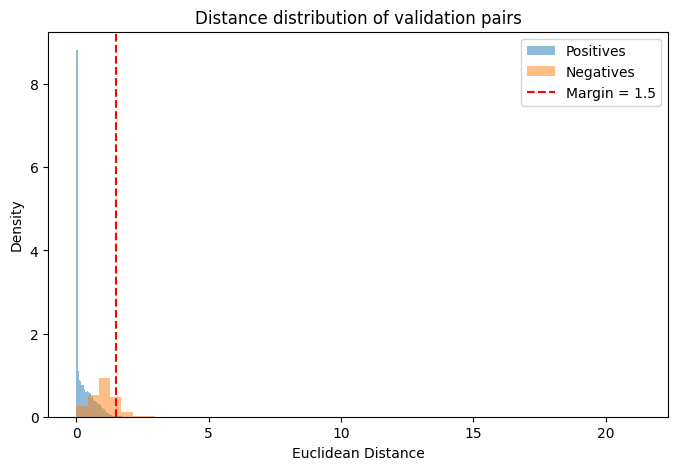

In [202]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(pos_dists, bins=50, alpha=0.5, label='Positives', density=True)
plt.hist(neg_dists, bins=50, alpha=0.5, label='Negatives', density=True)
plt.axvline(margin, color='r', linestyle='--', label=f'Margin = {margin}')
plt.xlabel('Euclidean Distance')
plt.ylabel('Density')
plt.legend()
plt.title('Distance distribution of validation pairs')
plt.show()

In [203]:
# For negatives (label=0), sort by distance ascending
neg_sort_indices = torch.argsort(neg_dists)
worst_neg_indices = torch.where(all_labels == 0)[0][neg_sort_indices[:20]]  # top 20 false positives

# Make sure val_df is the DataFrame that was used to create the Validation Dataset
# (it must contain the columns 'question1' and 'question2')

for global_idx in worst_neg_indices.tolist():
    row = val_df.iloc[global_idx]          # global_idx matches DataLoader order
    dist_val = all_dists[global_idx].item()
    print(f"Dist: {dist_val:.4f}")
    print(f"Q1: {row['question1']}")
    print(f"Q2: {row['question2']}")
    print("---")

Dist: 0.0000
Q1: how does startupnation . com make money ?
Q2: how does onmogul . com make money ?
---
Dist: 0.0000
Q1: how is joyable doing in 2016 ?
Q2: how is xignite doing in 2016 ?
---
Dist: 0.0000
Q1: how safe is papua new guinea , and how does it's crime rate compare to albania's ?
Q2: how safe is papua new guinea , and how does it's crime rate compare to botswana's ?
---
Dist: 0.0000
Q1: how did zeus rule his family and what kind of relationship did he have with ares , his son ?
Q2: how did zeus rule his family and what kind of relationship did he have with dionysus , his son ?
---
Dist: 0.0000
Q1: where does the water from the great lakes come from , and how does these lakes wildlife compare to lake ladoga ?
Q2: where does the water from the great lakes come from , and how does these lakes wildlife compare to lake sniardwi ?
---
Dist: 0.0000
Q1: what do you think of commonfig . com ?
Q2: what do you think of thedcdesigns . com ?
---
Dist: 0.0000
Q1: i own a domain name on blue

In [ ]:
class QuoraTokenizer:
    def __init__(self, config=token_cfg):
        self.config = config
        self.vocabs = {}
        self.idx2word = {}
        self.mask_words = None
        self.vocab_size = config.VOCAB_SIZE

    def build_vocabs(self, df):
        counter = Counter()
        question1 = df["question1"]
        question2 = df["question2"]
        for q1, q2 in zip(question1, question2):
            counter.update(q1.split())
            counter.update(q2.split())
        most_common = counter.most_common(self.config.VOCAB_SIZE - 2)
        self.vocabs = {
            self.config.PAD_TOKEN: self.config.PAD_IDX,
            self.config.UNK_TOKEN: self.config.UNK_IDX
        }
        for idx, (word, _) in enumerate(most_common, start=2):
            self.vocabs[word] = idx
        self.idx2word = {v: k for k, v in self.vocabs.items()}
        self.vocab_size = len(self.vocabs)
        self._build_stop_mask()
        print(">>> Vocabs created!")

    def _build_stop_mask(self):
        stop_set = set(stopwords.words("english"))
        custom = {
            '?', '!', '.', ',', '-', '...', '..', '/', '\\', '(', ')', '"', "'", '<PAD>', "what's",
        }
        stop_set.update(custom)

        mask = torch.ones(len(self.vocabs))
        for word, idx in self.vocabs.items():
            if word in stop_set:
                mask[idx] = 0.0
        self.stop_mask = mask

    def encode(self, text):
        tokens = text.split()
        ids = [self.vocabs.get(t, self.vocabs[self.config.UNK_TOKEN]) for t in tokens]
        # truncate
        ids = ids[:self.config.MAX_LENGTH]
        # pad
        ids += [self.vocabs[self.config.PAD_TOKEN]] * (self.config.MAX_LENGTH - len(ids))
        return ids

    def decode(self, ids, remove_pad=True):
        pad_id = self.vocabs[self.config.PAD_TOKEN]
        return " ".join(
            self.idx2word.get(i, self.config.UNK_TOKEN) for i in ids
            if not (remove_pad and i == pad_id)
        )

    def save(self, path):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        payload = {
            "max_length": self.config.MAX_LENGTH,
            "vocab_size": self.vocab_size,
            "special_tokens": {
                "pad": self.config.PAD_TOKEN,
                "unk": self.config.UNK_TOKEN
            },
            "vocabs": self.vocabs,
            "idx2word": {str(k): v for k, v in self.idx2word.items()},  # keys as strings for JSON
            "stop_mask": self.stop_mask.tolist() if self.stop_mask is not None else None
        }
        with open(path, 'w', encoding='utf-8') as f:
            json.dump(payload, f, ensure_ascii=False, indent=2)
        print(f">>> Tokenizer saved to {path}")

    def decode_to_tokens(self, ids, remove_pad=True):
        """
        Convert a list of token IDs back to a list of tokens.
        ids: list[int] or 1D tensor
        Returns: List[str]
        """
        pad_id = self.vocabs[self.config.PAD_TOKEN]
        tokens = []
        for i in ids:
            i = int(i)
            if remove_pad and i == pad_id:
                continue
            token = self.idx2word.get(i, self.config.UNK_TOKEN)
            tokens.append(token)
        return tokens
    
    def get_active_mask(self, ids):
        """
        Return a boolean mask of the same length as ids.
        True  → token is NOT padding AND NOT a stop‑word/char.
        False → token is either padding or a stop‑word (masked out by the model).
        ids: list[int] or 1D tensor
        Returns: torch.BoolTensor
        """
        if not isinstance(ids, torch.Tensor):
            ids = torch.tensor(ids)
        pad_id = self.vocabs[self.config.PAD_TOKEN]
        pad_mask = ids != pad_id
    
        if self.stop_mask is not None:
            # stop_mask: [vocab_size] with 0 for stop words, 1 for normal
            stop_mask_per_token = self.stop_mask[ids]  # 1 = keep, 0 = stop
            active = pad_mask & (stop_mask_per_token == 1)
        else:
            active = pad_mask
        return active

    def save_label_mapping(self, path):
        path = Path(path)
        label_mapping = {"0": "different", "1": "duplicated"}
        with open(path, "w", encoding="utf-8") as f:
            json.dump(label_mapping, f, ensure_ascii=False, indent=2)
            print(">>> Label mapping saved!")
            
    @classmethod
    def load(cls, path, config=token_cfg):
        
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # Create a new tokenizer using the given config
        tokenizer = cls(config=config)
        tokenizer.vocabs = data['vocabs']
        tokenizer.idx2word = {int(k): v for k, v in data['idx2word'].items()}
        if data['stop_mask'] is not None:
            tokenizer.stop_mask = torch.tensor(data['stop_mask'])
        else:
            tokenizer._build_stop_mask()  # fallback
        print(f">>> Tokenizer loaded from {path}")
        return tokenizer

In [ ]:
class QuoraSiameseClassifier(nn.Module):
    def __init__(self, vocab_size, config=model_cfg, embedding=None, stop_mask=None):
        super().__init__()
        self.config = config
        self.embedding = nn.Embedding(vocab_size, config.EMB_DIM)
        self.emb_norm = nn.LayerNorm(config.EMB_DIM)
        self.emb_dropout = nn.Dropout(config.EMB_DP)
        if stop_mask is not None:
            self.register_buffer("stop_mask", stop_mask)
        else:
            self.stop_mask = None
        if embedding is not None:
            print("Glove copied in Embedding Layer...")
            self.embedding.weight.data.copy_(embedding)
            self.embedding.weight.requires_grad = not config.FREEZE_TOKEN_EMBEDDING

        self.LSTM = nn.LSTM(
            input_size=config.EMB_DIM,
            hidden_size=config.HIDDEN_DIM,
            bidirectional=config.BIDIRECTIONAL,
            num_layers=config.NUM_LAYERS,
            dropout=config.DROPOUT if config.NUM_LAYERS > 1 else 0.0,
            batch_first=True
        )
        lstm_output_dim = config.HIDDEN_DIM*(2 if config.BIDIRECTIONAL else 1)
        self.lstm_norm = nn.LayerNorm(lstm_output_dim)
        self.attention = MultiHeadAttention(lstm_output_dim)
        if config.ATTENTION_PROJECTION:
            self.proj = nn.Linear(lstm_output_dim, config.PROJECT_DIM)
        else:
            self.proj = nn.Identity()
        self.attn_norm = nn.LayerNorm(lstm_output_dim)

    def _create_mask(self, question):
        return (question != 0).float()

    def _encode(self, question):
        emb = self.embedding(question)
        if self.config.LAYER_NORM_EMB:
            emb = self.emb_norm(emb)
        emb = self.emb_dropout(emb)
        mask = self._create_mask(question)
        if self.stop_mask is not None:
            token_stop_mask = self.stop_mask[question]
            mask = mask * token_stop_mask.float()
        out, _ = self.LSTM(emb)
        if self.config.LAYER_NORM_LSTM:
            out = self.lstm_norm(out)
        ctx = self.attention(out, mask)
        if self.config.LAYER_NORM_ATTENTION:
            ctx = self.attn_norm(ctx)
        return ctx

    def _encode_with_attention(self, question):
        emb = self.embedding(question)
        if self.config.LAYER_NORM_EMB:
            emb = self.emb_norm(emb)
        emb = self.emb_dropout(emb)
        mask = self._create_mask(question)
        if self.stop_mask is not None:
            token_stop_mask = self.stop_mask[question]
            mask = mask * token_stop_mask.float()
    
        out, _ = self.LSTM(emb)
        if self.config.LAYER_NORM_LSTM:
            out = self.lstm_norm(out)
    
        # Get context and attention weights
        ctx, attn_weights = self.attention(out, mask, return_weights=True)   # attn_weights: list of [B, L]
    
        if self.config.LAYER_NORM_ATTENTION:
            ctx = self.attn_norm(ctx)
    
        # Project (or identity)
        final = self.proj(ctx)
    
        return final, attn_weights, mask

    def forward(self, q1, q2):
        h1 = self._encode(q1)
        h2 = self._encode(q2)
        h1, h2 = self.proj(h1), self.proj(h2) 
        dist = F.pairwise_distance(h1, h2, p=2)
        
        return dist

In [ ]:
tokenizer = QuoraTokenizer(config=token_cfg)
tokenizer.build_vocabs(train_df)
vocabs = tokenizer.vocabs
vocab_size = tokenizer.vocab_size
stop_mask = tokenizer.stop_mask
# verify
print(">>> Vocab size:", tokenizer.vocab_size)
print(">>> First 10 vocab entries:", list(tokenizer.vocabs.items())[:10])
tokenizer.save(path_cfg.VOCABS_PATH)
tokenizer.save_label_mapping(path_cfg.LABEL_MAPPING_PATH)

In [204]:
import random

def show_false_positives_probs(model, tokenizer, val_df, all_dists, all_labels,
                               device, prob_threshold=0.55, num_examples=5,
                               combine_heads='mean'):
    """
    Finds false positives using probs = exp(-dist) and prints them
    with the attention display.
    """
    model.eval()
    dists = all_dists.cpu()
    labels = all_labels.cpu().long()
    probs = torch.exp(-dists)                     # your preferred conversion
    preds = (probs >= prob_threshold).long()      # 1 if duplicate

    # False positive: true label 0, predicted 1
    fp_mask = (labels == 0) & (preds == 1)
    fp_indices = fp_mask.nonzero(as_tuple=True)[0]

    if len(fp_indices) == 0:
        print("No false positives found.")
        return

    chosen = random.sample(fp_indices.tolist(), min(num_examples, len(fp_indices)))

    for i, idx in enumerate(chosen, start=1):
        row = val_df.iloc[idx]
        q1_text = row['question1']
        q2_text = row['question2']
        true_label = labels[idx].item()
        dist_val = dists[idx].item()
        prob_val = probs[idx].item()
        pred_val = preds[idx].item()

        print(f"--- Example {i} ---")
        show_single_pair(model, tokenizer, q1_text, q2_text,
                         true_label, pred_val, dist_val, prob_val,
                         device, combine_heads=combine_heads)

In [205]:
show_false_positives_probs(
    model, tokenizer, val_df, all_dists, all_labels,
    sys_cfg.DEVICE,
    prob_threshold=0.55,    # your optimal threshold on probability
    num_examples=5,
    combine_heads='mean'    # or 0, 1, ... for a specific head
)

--- Example 1 ---


AttributeError: 'QuoraSiameseClassifier' object has no attribute '_encode_with_attention'

In [69]:
@torch.no_grad()
def show_attention_per_head(model, tokenizer, question_text, device, max_heads=4):
    """
    Prints the tokens that the model actually sees (after stop‑word mask)
    and the attention weight per head for each token.
    """
    # Tokenize -> IDs -> tensor
    ids = tokenizer.encode(question_text)                     # list of ints, padded
    ids_tensor = torch.tensor([ids]).to(device)               # [1, L]

    # Get active mask from tokenizer (same as model uses internally)
    active_mask = tokenizer.get_active_mask(ids)              # BoolTensor [L]

    # Extract only the active tokens
    active_indices = active_mask.nonzero(as_tuple=True)[0]
    tokens = [tokenizer.idx2word[int(ids[i])] for i in active_indices]

    # Forward pass – use the new method that returns attention weights
    _, attn_weights, _ = model._encode_with_attention(ids_tensor)
    # attn_weights: list of [1, L] tensors (one per head)

    print(f"Question: {question_text}")
    print(f"Active tokens: {' '.join(tokens)}")
    for head_idx, w in enumerate(attn_weights[:max_heads]):
        w = w[0]                                 # shape [L]
        # Select only active tokens
        w_active = w[active_indices].cpu().numpy()
        # Normalise just for display (they already sum to 1 over all positions,
        # but after masking out zeros, sum may be <1. Still fine.)
        print(f"\n--- Head {head_idx+1} ---")
        for tok, weight in zip(tokens, w_active):
            bar = "█" * int(weight * 50)
            print(f"{tok:20s} {weight:.4f}  {bar}")

In [75]:
num_examples = 10
for rank, global_idx in enumerate(worst_neg_indices[:num_examples], start=1):
    idx = global_idx.item()                        # convert tensor → int
    row = val_df.iloc[idx]
    dist_val = all_dists[global_idx].item()        # this is fine, .item() already used
    print(f"\n{'='*60}")
    print(f"Example {rank} | dist = {dist_val:.4f}")
    print(f"Q1: {row['question1']}")
    print(f"Q2: {row['question2']}")

    q1_ids = tokenizer.encode(row['question1'])
    q1_tensor = torch.tensor([q1_ids]).to(device)
    q1_tokens = tokenizer.decode_to_tokens(q1_ids)
    print("\n--- Q1 Attention ---")
    show_attention(model, q1_tensor, q1_tokens, device)

    q2_ids = tokenizer.encode(row['question2'])
    q2_tensor = torch.tensor([q2_ids]).to(device)
    q2_tokens = tokenizer.decode_to_tokens(q2_ids)
    print("\n--- Q2 Attention ---")
    show_attention(model, q2_tensor, q2_tokens, device)


Example 1 | dist = 0.0000
Q1: how does startupnation . com make money ?
Q2: how does onmogul . com make money ?

--- Q1 Attention ---

--- Head 1 ---
<UNK>                0.9795 ████████████████████████████████████████████████
com                  0.0020 
make                 0.0161 
money                0.0023 

--- Head 2 ---
<UNK>                0.9999 █████████████████████████████████████████████████
com                  0.0000 
make                 0.0000 
money                0.0001 

--- Head 3 ---
<UNK>                0.9999 █████████████████████████████████████████████████
com                  0.0000 
make                 0.0000 
money                0.0000 

--- Head 4 ---
<UNK>                0.9997 █████████████████████████████████████████████████
com                  0.0000 
make                 0.0000 
money                0.0003 

--- Q2 Attention ---

--- Head 1 ---
<UNK>                0.9795 ████████████████████████████████████████████████
com                  0.0020

In [94]:
import random

@torch.no_grad()
def show_random_false_positives(model, tokenizer, val_df, all_dists, all_labels, device,
                                threshold=0.55, num=5):
    """
    Show *random* false positives (label=0, pred=1) with attention bars.
    Each sample header shows raw label (0/1) and prediction (0/1).
    """
    model.eval()
    labels_np = all_labels.cpu().numpy()
    dists_np  = all_dists.cpu().numpy()
    preds = (dists_np < threshold).astype(int)       # 1 = duplicate, 0 = different

    # false positive: true label = 0, predicted = 1
    fp_mask = (labels_np == 0) & (preds == 1)
    fp_indices = fp_mask.nonzero()[0]

    if len(fp_indices) == 0:
        print("No false positives found.")
        return

    # randomly sample `num` indices from the list of false positives
    chosen = random.sample(list(fp_indices), min(num, len(fp_indices)))

    for idx in chosen:
        row = val_df.iloc[idx]
        q1_text = row['question1']
        q2_text = row['question2']
        dist_val = dists_np[idx]

        q1_ids = tokenizer.encode(q1_text)
        q2_ids = tokenizer.encode(q2_text)
        q1_tensor = torch.tensor([q1_ids]).to(device)
        q2_tensor = torch.tensor([q2_ids]).to(device)

        # Header with exact numbers – no interpretation
        print(f"\n{'='*60}")
        print(f"True label: 0   |   Predicted: 1   ✗   |   Dist: {dist_val:.4f}   (thresh={threshold})")
        print(f"Q1: {q1_text}")

        # ---------- Q1 attention ----------
        _, attn_weights, mask = model._encode_with_attention(q1_tensor)
        active_mask = mask[0].cpu().bool()
        full_tokens = [tokenizer.idx2word.get(int(i), tokenizer.config.UNK_TOKEN) for i in q1_ids]
        active_tokens = [full_tokens[i] for i in range(len(full_tokens)) if active_mask[i]]

        for head_idx, w in enumerate(attn_weights[:4]):          # show 4 heads
            w_active = w[0][active_mask].cpu().numpy()
            print(f"\n--- Q1 Head {head_idx+1} ---")
            for tok, weight in zip(active_tokens, w_active):
                bar = "█" * int(weight * 50)
                print(f"{tok:20s} {weight:.4f}  {bar}")

        # ---------- Q2 attention ----------
        print(f"\nQ2: {q2_text}")

        _, attn_weights, mask = model._encode_with_attention(q2_tensor)
        active_mask = mask[0].cpu().bool()
        full_tokens = [tokenizer.idx2word.get(int(i), tokenizer.config.UNK_TOKEN) for i in q2_ids]
        active_tokens = [full_tokens[i] for i in range(len(full_tokens)) if active_mask[i]]

        for head_idx, w in enumerate(attn_weights[:4]):
            w_active = w[0][active_mask].cpu().numpy()
            print(f"\n--- Q2 Head {head_idx+1} ---")
            for tok, weight in zip(active_tokens, w_active):
                bar = "█" * int(weight * 50)
                print(f"{tok:20s} {weight:.4f}  {bar}")

        print("=" * 60)

In [95]:
show_random_false_positives(model, tokenizer, val_df, all_dists, all_labels,
                            sys_cfg.DEVICE, threshold=0.55, num=5)


True label: 0   |   Predicted: 1   ✗   |   Dist: 0.3072   (thresh=0.55)
Q1: how do you make your facial hair grow faster ?

--- Q1 Head 1 ---
make                 0.0001  
facial               0.0008  
hair                 0.0199  
grow                 0.5550  ███████████████████████████
faster               0.4242  █████████████████████

--- Q1 Head 2 ---
make                 0.0002  
facial               0.0014  
hair                 0.0368  █
grow                 0.4577  ██████████████████████
faster               0.5040  █████████████████████████

--- Q1 Head 3 ---
make                 0.0029  
facial               0.0107  
hair                 0.0585  ██
grow                 0.5449  ███████████████████████████
faster               0.3831  ███████████████████

--- Q1 Head 4 ---
make                 0.0001  
facial               0.0017  
hair                 0.0415  ██
grow                 0.5731  ████████████████████████████
faster               0.3836  ███████████████████

Q2: do

In [57]:
with torch.no_grad():
    batch = next(iter(val_dataloader))
    q1 = batch['q1'].to(sys_cfg.DEVICE)
    h = model._encode(q1[:32])
    final = model.proj(h)                      # <-- add this
    var_per_dim = final.var(dim=0)
    print(f"Variance per dim – mean: {var_per_dim.mean():.4f}, max: {var_per_dim.max():.4f}, min: {var_per_dim.min():.4f}")

Variance per dim – mean: 0.0017, max: 0.0282, min: 0.0000


In [206]:
with torch.no_grad():
    batch = next(iter(val_dataloader))
    q1 = batch['q1'].to(sys_cfg.DEVICE)
    h = model._encode(q1[:32])   # take a batch
    print("Variance per dimension:", h.var(dim=0).mean().item())

Variance per dimension: 0.001957190688699484


In [207]:
@torch.no_grad()
def get_embeddings_and_labels(model, loader, device):
    model.eval()
    h1_list, h2_list, labels_list = [], [], []
    for batch in tqdm(loader, desc="Extracting embeddings"):
        q1 = batch["q1"].to(device)
        q2 = batch["q2"].to(device)
        labels = batch["label"].to(device)

        # Directly use internal encode + projection
        ctx1 = model._encode(q1)
        ctx2 = model._encode(q2)
        vec1 = model.proj(ctx1)   # final representation
        vec2 = model.proj(ctx2)

        h1_list.append(vec1.cpu())
        h2_list.append(vec2.cpu())
        labels_list.append(labels.cpu())

    return (torch.cat(h1_list),
            torch.cat(h2_list),
            torch.cat(labels_list))

# Run it
h1, h2, labels = get_embeddings_and_labels(model, val_dataloader, sys_cfg.DEVICE)

# Basic statistics
print("Embedding shape:", h1.shape)   # [N, D]
print(f"Positive pairs: {(labels==1).sum().item()}")
print(f"Negative pairs: {(labels==0).sum().item()}")

# 1. Overall embedding variance per dimension (averaged over all vectors)
all_emb = torch.cat([h1, h2], dim=0)                     # [2N, D]
var_per_dim = all_emb.var(dim=0)                         # [D]
print("\n--- Variance per dimension (all embeddings) ---")
print(f"Mean: {var_per_dim.mean():.4f},  Max: {var_per_dim.max():.4f},  Min: {var_per_dim.min():.4f}")

# 2. Mean squared difference per dimension, split by label
diff = h1 - h2                                           # [N, D]
sq_diff = diff ** 2

pos_sq_mean = sq_diff[labels == 1].mean(dim=0)           # [D]
neg_sq_mean = sq_diff[labels == 0].mean(dim=0)

print("\n--- Mean squared diff (positive pairs) ---")
print(f"Mean: {pos_sq_mean.mean():.4f},  Max: {pos_sq_mean.max():.4f}")

print("\n--- Mean squared diff (negative pairs) ---")
print(f"Mean: {neg_sq_mean.mean():.4f},  Max: {neg_sq_mean.max():.4f}")

# 3. Dimension importance = how much larger negative distance is than positive
dim_importance = neg_sq_mean - pos_sq_mean
top_k = min(10, len(dim_importance))
top_dims = dim_importance.topk(top_k)
print(f"\nTop {top_k} dimensions separating pos/neg pairs:")
for idx, val in zip(top_dims.indices, top_dims.values):
    print(f"  dim {idx.item():4d}: importance {val.item():.4f}")

Extracting embeddings:   0%|          | 0/316 [00:00<?, ?it/s]

Embedding shape: torch.Size([40429, 768])
Positive pairs: 14926
Negative pairs: 25503

--- Variance per dimension (all embeddings) ---
Mean: 0.0028,  Max: 0.0925,  Min: 0.0001

--- Mean squared diff (positive pairs) ---
Mean: 0.0006,  Max: 0.0213

--- Mean squared diff (negative pairs) ---
Mean: 0.0047,  Max: 0.1547

Top 10 dimensions separating pos/neg pairs:
  dim  334: importance 0.1334
  dim  210: importance 0.1284
  dim  220: importance 0.1219
  dim  189: importance 0.1205
  dim  515: importance 0.1202
  dim    8: importance 0.1154
  dim  760: importance 0.1124
  dim  185: importance 0.1103
  dim  564: importance 0.1096
  dim  659: importance 0.0992


In [208]:
@torch.no_grad()
def variance_all_stages(model, dataloader, device):
    """
    Uses the same first batch for all measurements.
    Prints per‑dim variance: mean, max, min for:
      - pooled embedding
      - pooled LSTM
      - attention context (before projection)
      - final projected vector (used for distance)
    """
    model.eval()
    batch = next(iter(dataloader))
    q1 = batch['q1'][:128].to(device)          # use up to 128 samples, adjust as you like
    mask = model._create_mask(q1).unsqueeze(-1)

    # Embedding
    emb = model.embedding(q1)
    if model.config.LAYER_NORM_EMB:
        emb = model.emb_norm(emb)
    emb = model.emb_dropout(emb)
    emb_pooled = (emb * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

    # LSTM
    out, _ = model.LSTM(emb)
    if model.config.LAYER_NORM_LSTM:
        out = model.lstm_norm(out)
    lstm_pooled = (out * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

    # Attention (before projection)
    ctx = model.attention(out, mask.squeeze(-1))
    if model.config.LAYER_NORM_ATTENTION:
        ctx = model.attn_norm(ctx)

    # Final projection (as used in forward)
    final = model.proj(ctx)

    # Print per‑dim variance for each stage
    for name, tensor in [
        ("Embedding pooled", emb_pooled),
        ("LSTM pooled", lstm_pooled),
        ("Attention context", ctx),
        ("Projected final", final)
    ]:
        var = tensor.var(dim=0)
        print(f"{name:20s} | mean var: {var.mean():.5f}  max: {var.max():.5f}  min: {var.min():.6f}")


In [209]:
variance_all_stages(model, val_dataloader, sys_cfg.DEVICE)

Embedding pooled     | mean var: 0.13998  max: 0.22388  min: 0.078984
LSTM pooled          | mean var: 0.00028  max: 0.02285  min: 0.000000
Attention context    | mean var: 0.00312  max: 0.11830  min: 0.000060
Projected final      | mean var: 0.00312  max: 0.11830  min: 0.000060
